(7043, 21)
------ 统计有多少缺失数据 -------
------ revision ------
str
11
0
特征shape:(7043, 19)
目标shape:(7043,)
流失比例:26.54%
编码后特征shape:(7043, 30)
X_encoded编码后的列数：30
添加新特征后X.shape():(7043, 32)
最终特征列数:32


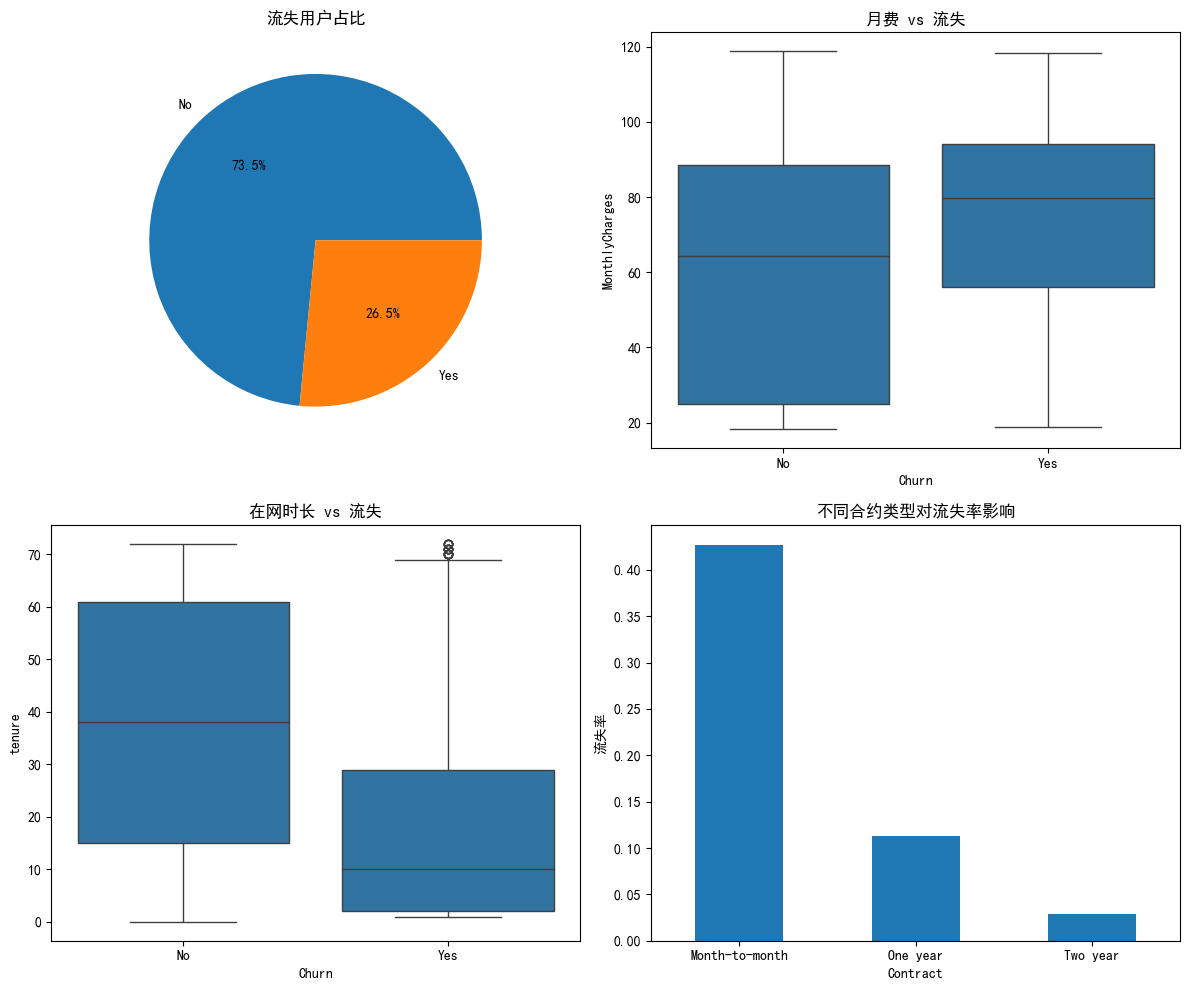

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#plt.title('流失用户占比')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
'''
print('### 数据类型 ###')
print(df.dtypes)
'''


# #00------->转换重要数据str为float64
print('------ 统计有多少缺失数据 -------')
#print(df.isnull().sum()) #----->发现TotalCharges列异常，应该str转为float64看看
print('------ revision ------')
print(df['TotalCharges'].dtype)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum()) #-->会显示数字大于0，即有nan数据
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df['TotalCharges'].isnull().sum())


# #01 -----> 分离特征和目标 ,  X是脱离customerID,Churn的数据，Y为目标
X = df.drop(['customerID','Churn'],axis=1)
Y = df['Churn'].map({'Yes':1, 'No':0})
print(f"特征shape:{X.shape}")
print(f"目标shape:{Y.shape}")
print(f"流失比例:{Y.mean():.2%}")


# #02 ----> 找出类别列
categorical_cols = X.select_dtypes(include=['object','string']).columns.tolist()
#print(f"类别列:\n{categorical_cols}")


# #03 ----> One-Hot编码,将gender列中，male, female换为1, 0
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"编码后特征shape:{X_encoded.shape}")
print(f"X_encoded编码后的列数：{len(X_encoded.columns)}")

# #04 -->加入新的特征玩玩
X_encoded['FamilySize'] =(
    (df['Partner'] == 'Yes').astype(int) +
    (df['Dependents'] == 'Yes').astype(int)
)
X_encoded['AvgMonthlyCost'] = df['TotalCharges'] / (df['tenure'] + 1)
print(f"添加新特征后X.shape():{X_encoded.shape}")
print(f"最终特征列数:{len(X_encoded.columns)}")

# #05 ---->导出
X_encoded.to_csv('../data/X_processed.csv', index=False)
Y.to_csv('../data/Y_processed.csv', index=False)

# #06 ---->可视化表现数据看看
fig, axes = plt.subplots(2, 2, figsize=(12,10))

    #图一：Churn流失
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0,0])
axes[0,0].set_title('流失用户占比')
axes[0,0].set_ylabel('')

    #图二：月费 vs 流失
sns.boxplot(x='Churn', y='MonthlyCharges',  data=df, ax=axes[0,1])
axes[0,1].set_title('月费 vs 流失')

    #图三：在网时长 vs 流失
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[1,0])
axes[1,0].set_title('在网时长 vs 流失')

    #图四：合约类型流失率
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
#print(f"abc:{contract_churn}")
contract_churn['Yes'].plot(kind='bar',ax=axes[1,1])
axes[1,1].set_title('不同合约类型对流失率影响')
axes[1,1].set_ylabel('流失率')
axes[1,1].tick_params(axis='x', rotation=0)

# # -->导出
plt.tight_layout()
plt.savefig('../output/basic_analysis.png', dpi=150)
plt.show()

### 实战1-把原始数据变成能喂给模型的数据
- `pd.to_numeric(df[列], errors='')`, errors= 'raise' #-->遇到非数值报错，
                                              'coerce' #-->遇到非数值转为NaN，
                                              'ignore' #-->保持原值不变
  --------
- `df['Churn'].map({'Yes': 1, 'No': 0})`转换Churn列数据，Yes转为1，No转为0，便于计算机处理
- ` ':' 格式说明符开始，'.2' 保留两位小数, '%' 转换为百分比格式`
- `df.select_dtype(include)` 按照include类型，筛选DataFrame, .columns返回列索引，.tolist()转换为列表[]
- `pd.get_dummies(df, columns, drop_first)` One-Hot编码，处理多列columns的类别列，df特征矩阵，对于特征矩阵X(包含数值列和类别列), 计算机无法处理类别列，如gender列下的female和male，就要用One-hot编码进行转换, drop_first = True 删除每个类别列的第一个虚拟变量，避免多重共线性（数据冗余）